# V3 semantic active Pair Generator

Цель ноутбука — проверить стратегию `semantic_active_v21`.

`semantic_control_v21` использует расширенную 6D semantic basis и выбирает semantic-направление вероятностно.  
`semantic_active_v21` делает следующий шаг: генерирует несколько возможных semantic A/B-вопросов и выбирает наиболее полезный вопрос по heuristic `question_score`.

Важно: в V3 ещё нет обучаемой `Preference Model`. Здесь оценивается не «что понравится пользователю», а полезность вопроса:

- насколько вопрос покрывает неопределённые признаки `z_std`;
- достаточно ли варианты A/B различаются;
- не выходит ли пара за safety bounds;
- не повторяет ли она недавно заданные semantic-вопросы.

То есть V3 — это активный выбор следующего A/B-вопроса, а полноценная model-based Preference Model остаётся следующим этапом.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / "personalization").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "personalization").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization


In [2]:
from personalization.batch_eval import run_batch_on_dataset, summarize_by_strategy, win_rates_vs_baseline, save_batch_outputs
from personalization.synthetic_dataset import (
    generate_synthetic_users_dataset,
    load_synthetic_users_dataset,
    save_synthetic_users_dataset,
    dataset_metadata,
)
from personalization.analysis import (
    merge_sessions_with_user_metadata,
    summarize_by_group,
    winners_by_group,
    win_rates_vs_baseline_by_group,
    compare_two_strategies_by_group,
    win_rate_between_strategies_by_group,
    plot_group_metric_bars,
    plot_win_rate_bars,
    plot_strategy_improvement_bars,
)
from personalization.plotting import plot_average_convergence_by_strategy, save_figure, use_article_style

use_article_style()

## 1. Загрузка fixed synthetic user dataset

Все стратегии тестируются на одном и том же dataset. Это делает сравнение воспроизводимым: у каждой стратегии одинаковые `z_target`, `feature_importance`, `noise_std` и пользовательские метаданные.

In [3]:
DATASET_PATH = PROJECT_ROOT / "outputs" / "datasets" / "synthetic_users_v21.csv"
DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    dataset = generate_synthetic_users_dataset(
        n_per_mode=100,
        seed=42,
        noise_std=0.05,
    )
    save_synthetic_users_dataset(
        dataset=dataset,
        dataset_path=DATASET_PATH,
        metadata_path=DATASET_PATH.with_suffix(".metadata.json"),
        metadata=dataset_metadata(
            dataset_name=DATASET_PATH.stem,
            n_per_mode=100,
            seed=42,
            noise_std=0.05,
            importance_sigma=0.35,
        ),
    )
else:
    dataset = load_synthetic_users_dataset(DATASET_PATH)

print("dataset shape:", dataset.shape)
dataset["target_mode"].value_counts()

dataset shape: (400, 48)


target_mode
random8d       100
semantic4d     100
semantic6d     100
archetype8d    100
Name: count, dtype: int64

## 2. Сравниваемые стратегии

В этом ноутбуке V3 сравнивается с предыдущими baselines:

- `random` — случайное направление в 8D;
- `uncertainty_axis` — вопрос по одной неопределённой оси;
- `semantic_control_v21` — semantic basis v2.1, выбор направления вероятностно;
- `semantic_active_v21` — V3, активный выбор semantic-вопроса;
- `hybrid_v21` — смесь random + semantic v2.1 + uncertainty;
- `hybrid_active_v21` — смесь random + semantic active + uncertainty.

In [4]:
STRATEGIES = [
    "random",
    "uncertainty_axis",
    "semantic_control_v21",
    "semantic_active_v21",
    "hybrid_v21",
    "hybrid_active_v21",
]

STRATEGY_DISPLAY = {
    "random": "random",
    "uncertainty_axis": "uncertainty_axis",
    "semantic_control_v21": "semantic_control_v21",
    "semantic_active_v21": "semantic_active_v21",
    "hybrid_v21": "hybrid_v21",
    "hybrid_active_v21": "hybrid_active_v21",
}

N_STEPS = 25
OUTPUT_PREFIX = "notebook_v3_semantic_active"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Batch-тест V3

In [5]:
sessions_df, curves = run_batch_on_dataset(
    dataset=dataset,
    strategies=STRATEGIES,
    n_steps=N_STEPS,
)

strategy_summary = summarize_by_strategy(sessions_df)
win_rates = win_rates_vs_baseline(sessions_df, baseline="random")

save_batch_outputs(
    sessions=sessions_df,
    strategy_summary=strategy_summary,
    win_rates=win_rates,
    output_dir=METRICS_DIR,
    prefix=OUTPUT_PREFIX,
)

sessions_with_meta = merge_sessions_with_user_metadata(sessions_df, dataset)
sessions_with_meta.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_sessions_with_meta.csv", index=False)

strategy_summary

,target_mode,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,archetype8d,semantic_active_v21,100,1.102635,0.378947,0.133465,0.280561,0.578662,57.677776,24.221786
4,archetype8d,semantic_control_v21,100,1.102635,0.476987,0.164772,0.322239,0.616510,44.705813,38.626852
0,archetype8d,hybrid_active_v21,100,1.102635,0.513053,0.170899,0.390215,0.700265,40.332236,39.495013
5,archetype8d,uncertainty_axis,100,1.102635,0.533740,0.259131,0.443866,0.760355,41.021812,35.416559
1,archetype8d,hybrid_v21,100,1.102635,0.545030,0.170712,0.421176,0.720359,36.142067,43.176286
2,archetype8d,random,100,1.102635,0.567765,0.214612,0.472785,0.770912,35.841547,41.039317
11,random8d,uncertainty_axis,100,2.212002,0.985761,0.415946,0.960684,1.546811,56.663880,11.459939
8,random8d,random,100,2.212002,0.996708,0.402072,0.979050,1.572826,55.800212,11.632861
7,random8d,hybrid_v21,100,2.212002,1.063145,0.422485,1.037094,1.572542,52.716079,11.436396
6,random8d,hybrid_active_v21,100,2.212002,1.073537,0.428281,1.042458,1.571624,52.232727,12.656742


In [6]:
win_rates

,target_mode,strategy,baseline,win_rate_final_distance,win_rate_best_distance
0,archetype8d,hybrid_active_v21,random,0.60,0.62
1,archetype8d,hybrid_v21,random,0.55,0.57
2,archetype8d,semantic_active_v21,random,0.88,0.94
3,archetype8d,semantic_control_v21,random,0.65,0.79
4,archetype8d,uncertainty_axis,random,0.61,0.58
5,random8d,hybrid_active_v21,random,0.45,0.47
6,random8d,hybrid_v21,random,0.48,0.47
7,random8d,semantic_active_v21,random,0.11,0.12
8,random8d,semantic_control_v21,random,0.08,0.08
9,random8d,uncertainty_axis,random,0.53,0.51


## 4. Средняя сходимость по режимам target

Графики показывают среднее расстояние от текущего `preference state` до скрытого `z_target` по шагам A/B-сессии.

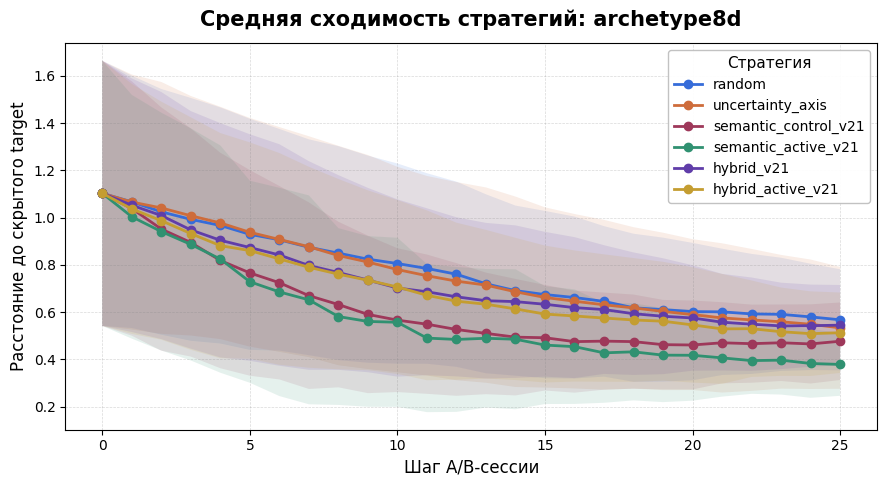

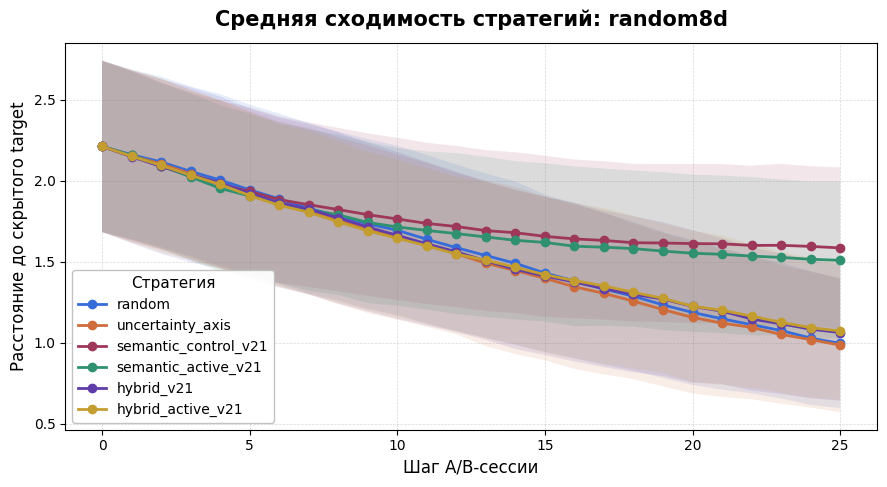

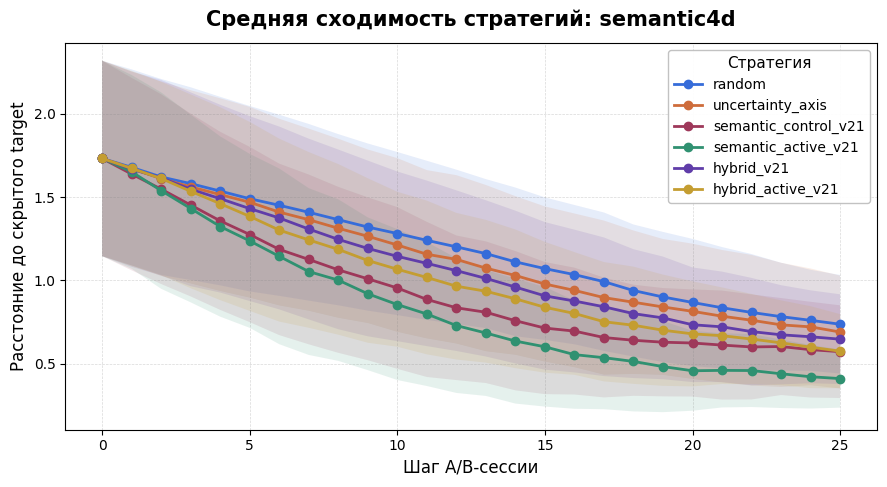

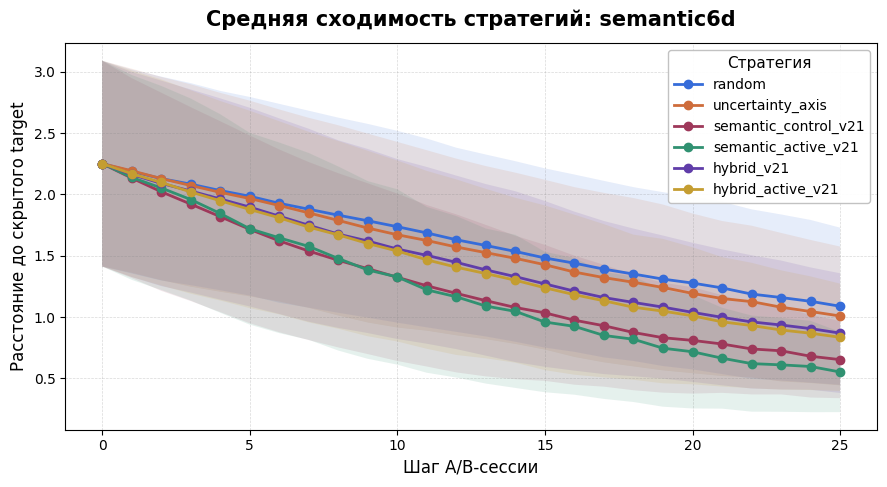

In [7]:
for target_mode in sorted(curves.keys()):
    curves_subset = {strategy: curves[target_mode][strategy] for strategy in STRATEGIES if strategy in curves[target_mode]}
    fig, ax = plot_average_convergence_by_strategy(
        curves_subset,
        strategy_display_names=STRATEGY_DISPLAY,
        title=f"Средняя сходимость стратегий: {target_mode}",
    )
    save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_convergence_{target_mode}.png")
    plt.show()

## 5. Победители по target_mode

In [8]:
target_mode_summary = summarize_by_group(sessions_with_meta, ["target_mode"])
target_mode_winners = winners_by_group(target_mode_summary, ["target_mode"])
target_mode_win_rates = win_rates_vs_baseline_by_group(sessions_with_meta, ["target_mode"])

target_mode_summary.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_target_mode_group_summary.csv", index=False)
target_mode_winners.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_target_mode_winners.csv", index=False)
target_mode_win_rates.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_target_mode_win_rates.csv", index=False)

target_mode_winners

,target_mode,winner_strategy,users,winner_mean_final_distance
0,archetype8d,semantic_active_v21,100,0.378947
1,semantic4d,semantic_active_v21,100,0.410014
2,semantic6d,semantic_active_v21,100,0.551607
3,random8d,uncertainty_axis,100,0.985761


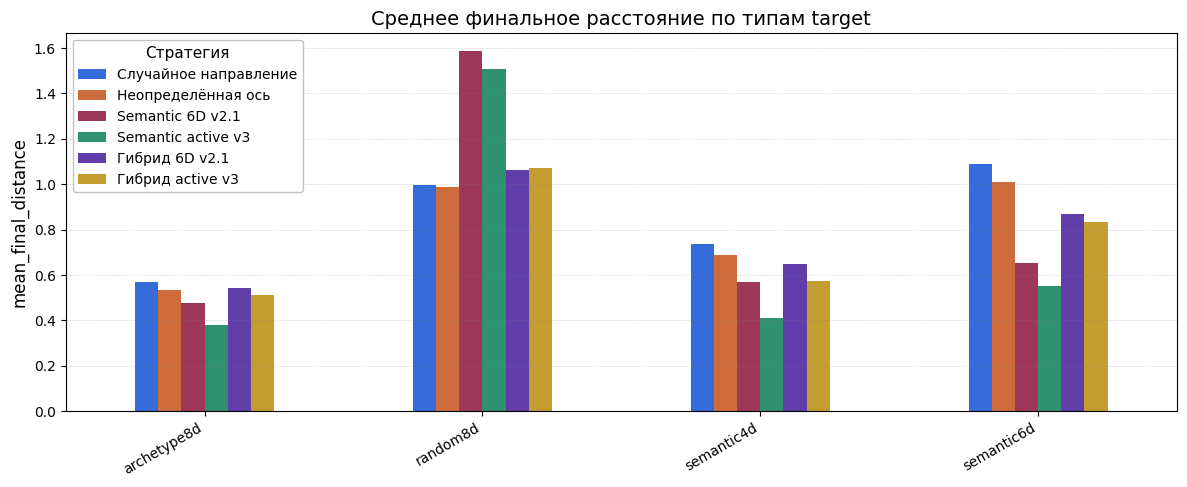

In [9]:
fig, ax = plot_group_metric_bars(
    target_mode_summary,
    group_col="target_mode",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Среднее финальное расстояние по типам target",
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_target_mode_mean_final_distance.png")
plt.show()

## 6. Анализ archetype8d по intensity

In [10]:
archetype_sessions = sessions_with_meta[sessions_with_meta["target_mode"] == "archetype8d"].copy()

intensity_summary = summarize_by_group(archetype_sessions, ["intensity_label"])
intensity_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["intensity_label"])

intensity_summary.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_intensity_group_summary.csv", index=False)
intensity_win_rates.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_intensity_win_rates.csv", index=False)

intensity_summary

,intensity_label,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,extreme,semantic_active_v21,16,1.382814,0.458711,0.254879,0.372386,0.785348,60.409439,19.359674
4,extreme,semantic_control_v21,16,1.382814,0.547728,0.250569,0.455746,0.825583,51.460459,23.859111
0,extreme,hybrid_active_v21,16,1.382814,0.621731,0.305688,0.537064,0.933360,44.116070,28.928784
2,extreme,random,16,1.382814,0.627439,0.327190,0.546072,0.954679,45.520765,25.138565
1,extreme,hybrid_v21,16,1.382814,0.665535,0.263291,0.544381,0.937994,38.378069,31.608590
5,extreme,uncertainty_axis,16,1.382814,0.719503,0.444891,0.609143,0.987428,39.878168,25.301019
9,mild,semantic_active_v21,15,0.633372,0.324264,0.072330,0.219307,0.383104,36.743030,34.968078
10,mild,semantic_control_v21,15,0.633372,0.426521,0.175027,0.255606,0.446882,16.186087,52.292898
8,mild,random,15,0.633372,0.443981,0.124184,0.306414,0.506998,7.349563,65.705452
11,mild,uncertainty_axis,15,0.633372,0.453921,0.115475,0.338716,0.529866,12.171314,48.378003


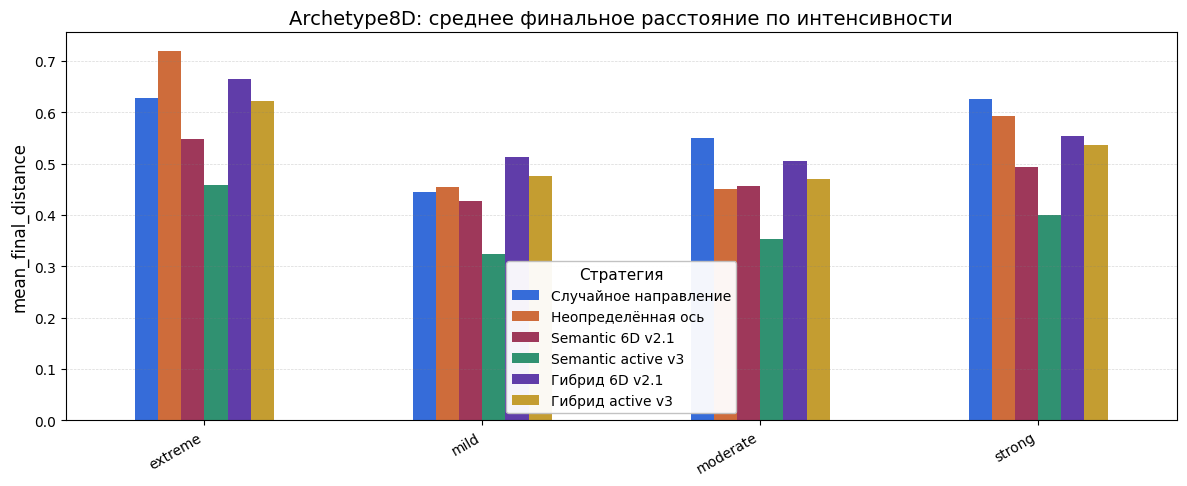

In [11]:
fig, ax = plot_group_metric_bars(
    intensity_summary,
    group_col="intensity_label",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Archetype8D: среднее финальное расстояние по интенсивности",
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_intensity_mean_final_distance.png")
plt.show()

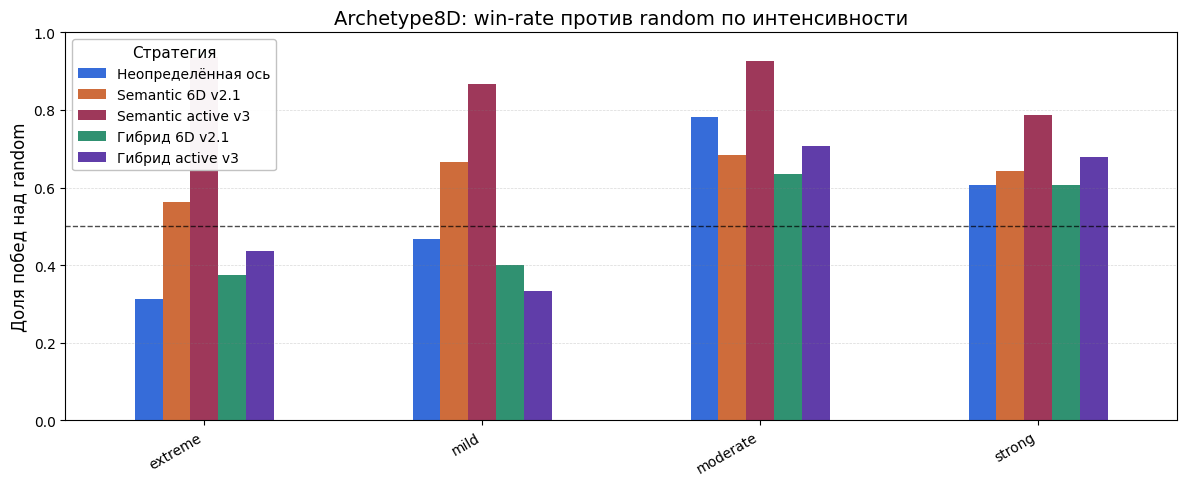

In [12]:
fig, ax = plot_win_rate_bars(
    intensity_win_rates,
    group_col="intensity_label",
    metric_col="win_rate_final_distance",
    strategy_order=STRATEGIES,
    title="Archetype8D: win-rate против random по интенсивности",
    figsize=(12, 5),
)
save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_intensity_win_rate.png")
plt.show()

## 7. Анализ archetype8d по основному архетипу

In [13]:
main_archetype_summary = summarize_by_group(archetype_sessions, ["main_archetype"])
main_archetype_win_rates = win_rates_vs_baseline_by_group(archetype_sessions, ["main_archetype"])

main_archetype_summary.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_main_archetype_group_summary.csv", index=False)
main_archetype_win_rates.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_main_archetype_win_rates.csv", index=False)

main_archetype_summary.head(20)

,main_archetype,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
3,bass_lover,semantic_active_v21,7,1.077502,0.332930,0.104913,0.258589,0.503561,67.679806,10.072760
2,bass_lover,random,7,1.077502,0.397822,0.135922,0.357954,0.691390,58.330740,29.236898
0,bass_lover,hybrid_active_v21,7,1.077502,0.440470,0.138571,0.375178,0.641995,54.351592,22.581634
5,bass_lover,uncertainty_axis,7,1.077502,0.454155,0.144945,0.414871,0.706812,55.433790,16.929935
4,bass_lover,semantic_control_v21,7,1.077502,0.518051,0.135142,0.285219,0.554388,49.620014,13.373504
1,bass_lover,hybrid_v21,7,1.077502,0.525639,0.128534,0.391514,0.665608,47.295184,19.737756
9,basshead,semantic_active_v21,11,1.671107,0.455611,0.202488,0.362911,0.860918,71.268319,11.191704
10,basshead,semantic_control_v21,11,1.671107,0.569370,0.137210,0.377619,0.774207,61.160091,21.157503
7,basshead,hybrid_v21,11,1.671107,0.632098,0.252083,0.548825,0.985731,60.546651,13.552886
6,basshead,hybrid_active_v21,11,1.671107,0.643947,0.304711,0.588942,1.023372,59.817913,15.910286


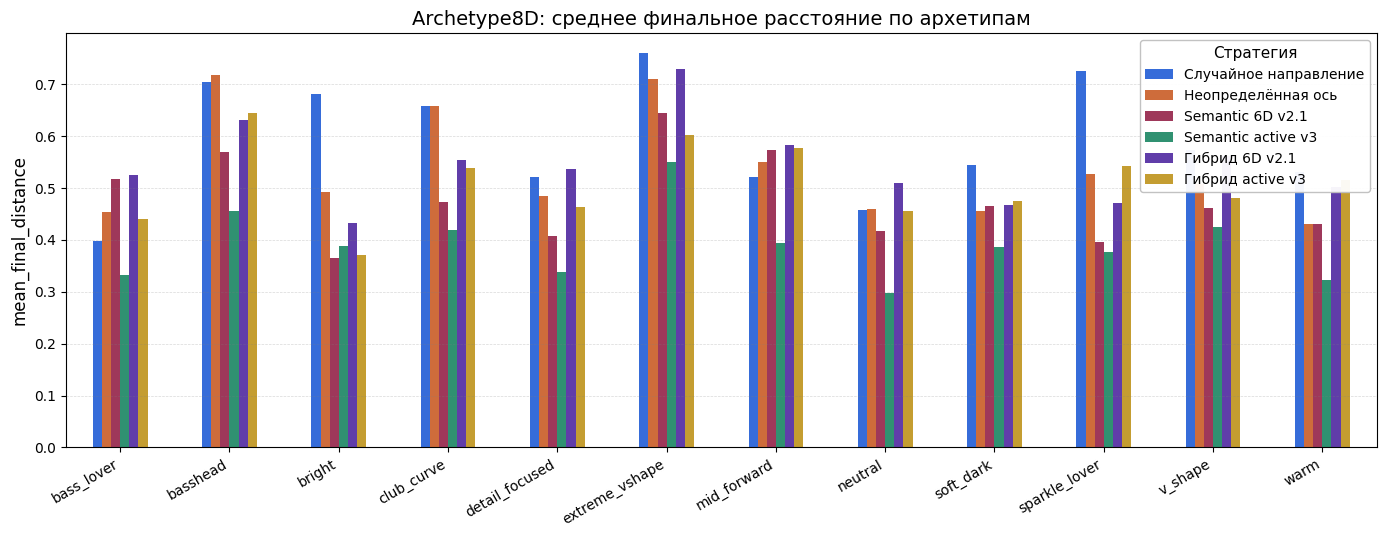

In [14]:
fig, ax = plot_group_metric_bars(
    main_archetype_summary,
    group_col="main_archetype",
    metric="mean_final_distance",
    strategy_order=STRATEGIES,
    title="Archetype8D: среднее финальное расстояние по архетипам",
    figsize=(14, 5.5),
)
save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_main_archetype_mean_final_distance.png")
plt.show()

## 8. Сравнение V3 с semantic_control_v21

Здесь сравнивается старшая semantic-стратегия v2.1 (`semantic_control_v21`) и V3 active selector (`semantic_active_v21`). Положительный `improvement_pct` означает, что V3 уменьшил среднее финальное расстояние относительно v2.1.

In [16]:
v3_vs_v21_by_archetype = compare_two_strategies_by_group(
    main_archetype_summary,
    group_col="main_archetype",
    old_strategy="semantic_control_v21",
    new_strategy="semantic_active_v21",
    metric="mean_final_distance",
)

v3_vs_v21_win_rates = win_rate_between_strategies_by_group(
    archetype_sessions,
    group_cols=["main_archetype"],
    strategy_a="semantic_active_v21",
    strategy_b="semantic_control_v21",
    metric="final_distance",
)

v3_vs_v21_by_archetype.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_v3_vs_v21_by_archetype.csv", index=False)
v3_vs_v21_win_rates.to_csv(METRICS_DIR / f"{OUTPUT_PREFIX}_v3_vs_v21_win_rates_by_archetype.csv", index=False)

v3_vs_v21_by_archetype

,main_archetype,semantic_control_v21_mean_final_distance,semantic_active_v21_mean_final_distance,improvement_abs,improvement_pct,winner
0,bass_lover,0.518051,0.332930,0.185121,35.734080,semantic_active_v21
1,mid_forward,0.572645,0.394244,0.178401,31.153882,semantic_active_v21
2,neutral,0.418053,0.297099,0.120954,28.932628,semantic_active_v21
3,basshead,0.569370,0.455611,0.113759,19.979860,semantic_active_v21
4,warm,0.429846,0.323048,0.106798,24.845672,semantic_active_v21
5,extreme_vshape,0.644648,0.549841,0.094806,14.706684,semantic_active_v21
6,soft_dark,0.464848,0.387104,0.077744,16.724583,semantic_active_v21
7,detail_focused,0.406992,0.337625,0.069367,17.043924,semantic_active_v21
8,club_curve,0.472399,0.419631,0.052768,11.170200,semantic_active_v21
9,v_shape,0.461212,0.424585,0.036626,7.941321,semantic_active_v21


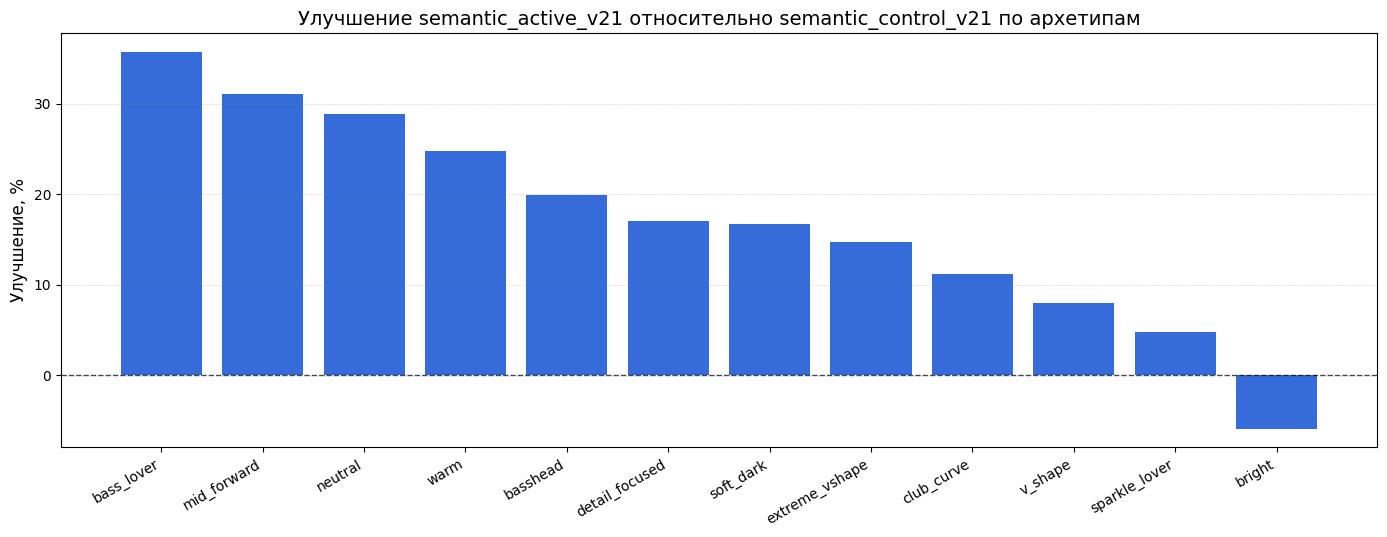

In [18]:
fig, ax = plot_strategy_improvement_bars(
    v3_vs_v21_by_archetype,
    group_col="main_archetype",
    value_col="improvement_pct",
    title="Улучшение semantic_active_v21 относительно semantic_control_v21 по архетипам",
    figsize=(14, 5.5),
)
save_figure(fig, FIGURES_DIR / f"{OUTPUT_PREFIX}_v3_vs_v21_improvement_by_archetype.png")
plt.show()

## Вывод по V3 semantic_active_v21

В данном эксперименте была проверена стратегия `semantic_active_v21`, которая использует расширенную semantic basis v2.1, но выбирает следующий A/B-вопрос не случайно, а по эвристическому question-usefulness score. В отличие от `semantic_control_v21`, стратегия V3 оценивает несколько возможных semantic-направлений и выбирает то, которое лучше покрывает текущую неопределённость preference state.

Результаты показывают, что `semantic_active_v21` стала лучшей стратегией во всех структурированных режимах: `semantic4d`, `semantic6d` и `archetype8d`. В режиме `archetype8d`, который моделирует реалистичных пользователей через архетипы и intensity, среднее финальное расстояние снизилось примерно до `0.379`, тогда как у `semantic_control_v21` оно составило около `0.515`, а у random baseline — около `0.568`.

Особенно важно, что `semantic_active_v21` выиграла у random baseline в `88%` сессий по `final_distance` и в `94%` сессий по `best_distance` на `archetype8d`. Это подтверждает, что активный выбор semantic-вопросов повышает устойчивость и скорость сходимости personalization loop.

Анализ по архетипам показал, что V3 улучшает V2.1 почти для всех пользовательских типов, включая `bass_lover`, `basshead`, `club_curve`, `mid_forward`, `warm`, `soft_dark` и `extreme_vshape`. Наиболее заметный выигрыш получен для `bass_lover` и `mid_forward`. Единственное ухудшение наблюдается для `bright`, однако в этой группе мало пользователей, поэтому результат требует дополнительной проверки.

В режиме `random8d` лучшей стратегией остаётся `uncertainty_axis`, а semantic-стратегии ожидаемо проигрывают, поскольку произвольный 8D-target не обязан лежать в semantic-подпространстве. Это подтверждает, что semantic_active является сильной стратегией именно для реалистичных, музыкально структурированных предпочтений, а не универсальной заменой поиску в полном 8D-пространстве.

Итог: `semantic_active_v21` можно считать текущей лучшей стратегией Pair Generator для реалистичных пользователей. Следующим этапом может быть V4, где к active Pair Generator будет добавлена отдельная Preference Model, прогнозирующая вероятность выбора `P(A > B)` по истории пользовательских A/B-ответов.